# Projeto 03 — Project Portfolio Management Analytics

## Objetivo

Este notebook tem como objetivo transformar a base bruta de projetos
(`data/raw/projects.csv`) em tabelas analíticas que permitam:

- Avaliar desempenho de prazo, custo e qualidade dos projetos;
- Medir a simultaneidade de projetos ao longo do tempo;
- Identificar sazonalidade e variações de volume por ano e mês;
- Gerar insumos para dashboards de BI e para modelos de Ciência de Dados.

## Período analisado

- Início: 2020-01-01
- Data de referência: 2026-08-18
- Total de projetos: 530

## 1. Preparação do ambiente

Nesta etapa, importamos as bibliotecas necessárias e configuramos
parâmetros globais, como a data de referência do portfólio.

In [3]:
# Bibliotecas principais
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Data de referência do portfólio (hoje, no contexto do projeto)
REFERENCE_DATE = pd.Timestamp("2026-08-18")

# Caminhos do projeto
BASE_DIR = Path.cwd().parent  # assume que o notebook está em /notebooks
RAW_FILE = BASE_DIR / "data" / "raw" / "projects.csv"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Data de referência:", REFERENCE_DATE.date())
print("Arquivo de entrada:", RAW_FILE)

Data de referência: 2026-08-18
Arquivo de entrada: /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/raw/projects.csv


## 2. Carregamento e preparação dos dados

Carregamos a base bruta de projetos e convertemos as colunas de data
e numéricas para os tipos corretos, garantindo consistência para
os cálculos seguintes.

In [5]:
# Carrega a base bruta de projetos
df = pd.read_csv(RAW_FILE)
print("Registros carregados:", len(df))
print("Colunas:", df.shape[1])
df.head(5)

Registros carregados: 530
Colunas: 20


,project_id,project_name,client_id,project_manager,business_unit,project_type,priority,complexity,planned_start_date,planned_end_date,actual_start_date,actual_end_date,planned_budget,actual_cost,planned_hours,actual_hours,team_size,project_status,final_quality_score,client_satisfaction_score
0,P0001,New Development - Vargas,C039,Ana Beatriz Alves,Manufacturing,New Development,Low,Medium,2023-02-11,2023-06-17,2023-02-20,2023-06-09,187894.32,217677.83,1112.9,1065.4,8,Completed,8.04,7.61
1,P0002,Integration - Ferreira,C003,Cauã Rocha,Finance,Integration,Critical,Low,2025-09-09,2025-11-02,2025-09-08,2025-10-31,42492.02,40081.45,471.8,494.9,3,Completed,8.67,7.72
2,P0003,Consulting - Souza Novais - EI,C026,Sra. Isabelly Câmara,Energy,Consulting,Low,Medium,2023-05-04,2023-09-18,2023-05-02,2023-08-29,156426.31,114713.85,870.5,1048.7,4,Completed,8.34,7.40
3,P0004,New Development - Caldeira,C001,Yago Leão,Technology,New Development,Low,High,2021-01-11,2021-09-19,2021-01-20,2021-08-16,463630.51,548223.10,2299.3,2525.2,9,Completed,8.06,7.24
4,P0005,New Development - Moura,C035,Otávio Fernandes,Energy,New Development,High,Medium,2023-03-14,2023-07-23,2023-03-12,2023-07-11,177604.59,198309.46,909.7,703.9,4,Completed,8.18,8.43


In [6]:
# Conversão das colunas de data
date_columns = [
    "planned_start_date",
    "planned_end_date",
    "actual_start_date",
    "actual_end_date",
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

# Conversão das colunas numéricas
numeric_columns = [
    "planned_budget",
    "actual_cost",
    "planned_hours",
    "actual_hours",
    "team_size",
    "final_quality_score",
    "client_satisfaction_score",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.head()

,project_id,project_name,client_id,project_manager,business_unit,project_type,priority,complexity,planned_start_date,planned_end_date,actual_start_date,actual_end_date,planned_budget,actual_cost,planned_hours,actual_hours,team_size,project_status,final_quality_score,client_satisfaction_score
0,P0001,New Development - Vargas,C039,Ana Beatriz Alves,Manufacturing,New Development,Low,Medium,2023-02-11,2023-06-17,2023-02-20,2023-06-09,187894.32,217677.83,1112.9,1065.4,8,Completed,8.04,7.61
1,P0002,Integration - Ferreira,C003,Cauã Rocha,Finance,Integration,Critical,Low,2025-09-09,2025-11-02,2025-09-08,2025-10-31,42492.02,40081.45,471.8,494.9,3,Completed,8.67,7.72
2,P0003,Consulting - Souza Novais - EI,C026,Sra. Isabelly Câmara,Energy,Consulting,Low,Medium,2023-05-04,2023-09-18,2023-05-02,2023-08-29,156426.31,114713.85,870.5,1048.7,4,Completed,8.34,7.40
3,P0004,New Development - Caldeira,C001,Yago Leão,Technology,New Development,Low,High,2021-01-11,2021-09-19,2021-01-20,2021-08-16,463630.51,548223.10,2299.3,2525.2,9,Completed,8.06,7.24
4,P0005,New Development - Moura,C035,Otávio Fernandes,Energy,New Development,High,Medium,2023-03-14,2023-07-23,2023-03-12,2023-07-11,177604.59,198309.46,909.7,703.9,4,Completed,8.18,8.43


### Verificação inicial

Antes de seguir, validamos rapidamente:

- Se não há datas reais posteriores à data de referência;
- Se a distribuição de status está de acordo com o esperado;
- Se não há valores nulos inesperados nas colunas-chave.

In [8]:
# Checagem de datas reais além da referência
datas_invalidas = df[
    df["actual_end_date"] > REFERENCE_DATE
]

print("Registros com actual_end_date > data de referência:", len(datas_invalidas))

Registros com actual_end_date > data de referência: 0


In [9]:
# Distribuição de status
print("\nDistribuição de status:")
print(df["project_status"].value_counts())


Distribuição de status:
project_status
Completed      360
Cancelled       74
On Hold         50
In Progress     41
Planned          5
Name: count, dtype: int64


In [10]:
# Nulos nas colunas-chave
print("\nValores nulos em colunas-chave:")
print(df[["planned_start_date", "planned_end_date", "project_status"]].isna().sum())


Valores nulos em colunas-chave:
planned_start_date    0
planned_end_date      0
project_status        0
dtype: int64


> **Insight:** nenhum projeto possui data real posterior à data de
> referência do portfólio, o que confirma que a base respeita
> corretamente o corte temporal de 18/08/2026. A distribuição de
> status mostra predominância de projetos concluídos, seguida por
> cancelados, em espera, em andamento e planejados — um padrão
> coerente com uma carteira madura de projetos.

## 3. Métricas por projeto

Nesta etapa, criamos indicadores de desempenho para cada projeto:

- Duração planejada e real;
- Variação de prazo (schedule variance), início (start variance) e
  término (end variance);
- Variação de custo (cost variance);
- Variação de horas;
- Indicadores binários de entrega no prazo e dentro do orçamento;
- Faixa de qualidade (quality band).

In [13]:
# Cria uma cópia para não alterar o dataframe original
analytics = df.copy()

# Duração planejada e real (em dias)
analytics["planned_duration_days"] = (
    analytics["planned_end_date"] - analytics["planned_start_date"]
).dt.days

analytics["actual_duration_days"] = (
    analytics["actual_end_date"] - analytics["actual_start_date"]
).dt.days

# Variação de prazo: real - planejado (positivo = atraso)
analytics["schedule_variance_days"] = np.where(
    analytics["actual_duration_days"].notna(),
    analytics["actual_duration_days"] - analytics["planned_duration_days"],
    np.nan,
)

# Atraso no início: positivo significa início posterior ao planejado
analytics["start_variance_days"] = (
    analytics["actual_start_date"]
    - analytics["planned_start_date"]
).dt.days

# Atraso no término: positivo significa término posterior ao planejado
analytics["end_variance_days"] = (
    analytics["actual_end_date"]
    - analytics["planned_end_date"]
).dt.days

# Variação de custo: real - planejado (positivo = estourou orçamento)
analytics["cost_variance"] = analytics["actual_cost"] - analytics["planned_budget"]

analytics["cost_variance_pct"] = np.where(
    analytics["planned_budget"] > 0,
    analytics["cost_variance"] / analytics["planned_budget"] * 100,
    np.nan,
)

# Variação de horas
analytics["hours_variance"] = analytics["actual_hours"] - analytics["planned_hours"]

analytics["hours_variance_pct"] = np.where(
    analytics["planned_hours"] > 0,
    analytics["hours_variance"] / analytics["planned_hours"] * 100,
    np.nan,
)

analytics[[
    "project_id",
    "planned_duration_days",
    "actual_duration_days",
    "schedule_variance_days",
    "start_variance_days",
    "end_variance_days",
    "cost_variance",
    "cost_variance_pct",
]].head()

,project_id,planned_duration_days,actual_duration_days,schedule_variance_days,start_variance_days,end_variance_days,cost_variance,cost_variance_pct
0,P0001,126,109.0,-17.0,9.0,-8.0,29783.51,15.851203
1,P0002,54,53.0,-1.0,-1.0,-2.0,-2410.57,-5.672995
2,P0003,137,119.0,-18.0,-2.0,-20.0,-41712.46,-26.665885
3,P0004,251,208.0,-43.0,9.0,-34.0,84592.59,18.245691
4,P0005,131,121.0,-10.0,-2.0,-12.0,20704.87,11.657846


In [14]:
# Flags de status
analytics["is_completed"] = analytics["project_status"] == "Completed"
analytics["is_cancelled"] = analytics["project_status"] == "Cancelled"

analytics["is_active_current"] = analytics["project_status"].isin(
    ["In Progress", "On Hold"]
)

analytics["is_pipeline"] = analytics["project_status"] == "Planned"

# Risco real de atraso na entrega:
# 1 = terminou depois da data planejada
# 0 = terminou na data planejada ou antes
# NaN = projeto ainda não concluído (sem desfecho real)
analytics["schedule_risk_flag"] = np.where(
    analytics["is_completed"],
    analytics["end_variance_days"] > 0,
    np.nan,
)

# Risco de estouro de orçamento:
# 1 = custo real maior que o orçamento planejado
# 0 = custo real dentro ou abaixo do orçamento
# NaN = projeto ainda não concluído (sem desfecho real)
analytics["cost_risk_flag"] = np.where(
    analytics["is_completed"],
    analytics["cost_variance"] > 0,
    np.nan,
)

# Entrega no prazo e dentro do orçamento (somente para concluídos)
analytics["completed_on_time"] = np.where(
    analytics["is_completed"],
    analytics["actual_end_date"] <= analytics["planned_end_date"],
    np.nan,
)

analytics["completed_within_budget"] = np.where(
    analytics["is_completed"],
    analytics["actual_cost"] <= analytics["planned_budget"],
    np.nan,
)

# Faixa de qualidade
analytics["quality_band"] = pd.cut(
    analytics["final_quality_score"],
    bins=[0, 5, 7, 8.5, 10],
    labels=["Critical", "Needs Improvement", "Good", "Excellent"],
    include_lowest=True,
)

# Ano e mês de início (para análises de sazonalidade)
analytics["start_year"] = analytics["planned_start_date"].dt.year
analytics["start_month"] = analytics["planned_start_date"].dt.month
analytics["start_month_name"] = analytics["planned_start_date"].dt.month_name()

analytics[[
    "project_id",
    "project_status",
    "schedule_risk_flag",
    "cost_risk_flag",
    "completed_on_time",
    "completed_within_budget",
    "quality_band",
]].head()

,project_id,project_status,schedule_risk_flag,cost_risk_flag,completed_on_time,completed_within_budget,quality_band
0,P0001,Completed,0.0,1.0,1.0,0.0,Good
1,P0002,Completed,0.0,0.0,1.0,1.0,Excellent
2,P0003,Completed,0.0,0.0,1.0,1.0,Good
3,P0004,Completed,0.0,1.0,1.0,0.0,Good
4,P0005,Completed,0.0,1.0,1.0,0.0,Good


### Indicadores agregados de desempenho

Vamos consolidar os principais indicadores de performance da
carteira: percentual de entregas no prazo, percentual dentro do
orçamento e distribuição das faixas de qualidade.

In [16]:
completed = analytics[analytics["is_completed"]]

pct_on_time = completed["completed_on_time"].mean() * 100
pct_within_budget = completed["completed_within_budget"].mean() * 100

print(f"Projetos concluídos: {len(completed)}")
print(f"Percentual entregue no prazo: {pct_on_time:.1f}%")
print(f"Percentual dentro do orçamento: {pct_within_budget:.1f}%")

print("\nDistribuição das faixas de qualidade:")
print(completed["quality_band"].value_counts())

Projetos concluídos: 360
Percentual entregue no prazo: 51.4%
Percentual dentro do orçamento: 38.9%

Distribuição das faixas de qualidade:
quality_band
Good                 274
Excellent             85
Needs Improvement      1
Critical               0
Name: count, dtype: int64


> **Insight:** este bloco revela o equilíbrio real da operação —
> quantos projetos concluídos respeitaram prazo e orçamento, e como
> a qualidade final se distribui entre as faixas. Esses números
> serão a base dos KPIs executivos do dashboard (ex.: % on-time
> delivery, % on-budget delivery, distribuição de qualidade).

## 4. Visualização: variação de prazo e custo

Vamos visualizar a distribuição da variação de prazo e de custo
para identificar padrões de atraso e estouro orçamentário.

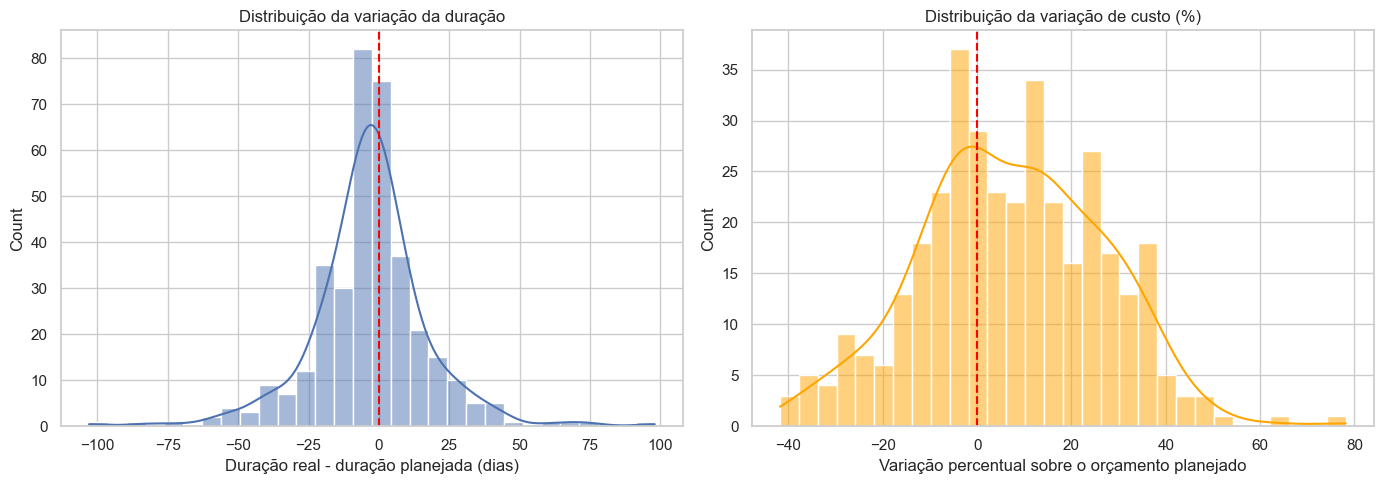

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    completed["schedule_variance_days"].dropna(),
    bins=30,
    kde=True,
    ax=axes[0],
)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribuição da variação da duração")
axes[0].set_xlabel("Duração real - duração planejada (dias)")

sns.histplot(
    completed["cost_variance_pct"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1],
    color="orange",
)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição da variação de custo (%)")
axes[1].set_xlabel("Variação percentual sobre o orçamento planejado")

plt.tight_layout()
plt.show()

> **Insight - variação da duração:** a duração real dos projetos tende a ser inferior à
> duração planejada, embora existam projetos com variações positivas
> relevantes. Essa métrica avalia a eficiência da duração planejada,
> mas não deve ser confundida com atraso da data final.
>
> **Insight - variação de custo:** a distribuição de custo está deslocada para valores
> positivos, indicando uma tendência de estouro orçamentário. Além
> disso, a cauda direita revela projetos com desvios extremos,
> recomendando investigação de escopo, estimativas iniciais,
> fornecedores e controle de mudanças.

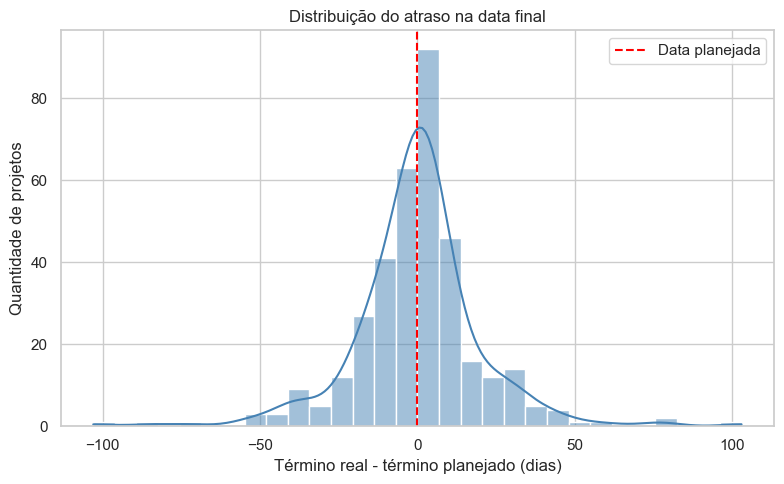

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    completed["end_variance_days"].dropna(),
    bins=30,
    kde=True,
    color="steelblue",
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Data planejada",
)

plt.title(
    "Distribuição do atraso na data final"
)

plt.xlabel(
    "Término real - término planejado (dias)"
)

plt.ylabel("Quantidade de projetos")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Snapshot mensal do portfólio

Nesta etapa, construímos uma linha por mês (de 2020-01 até
2026-08), medindo quantos projetos estavam ativos, quantos
iniciaram, quantos foram concluídos e quantos foram cancelados
em cada período. Essa é a base para analisar **simultaneidade**
e **sazonalidade**.

In [23]:
def build_monthly_snapshot(data, reference_date):
    """
    Gera uma linha por mês, calculando:

    - Projetos iniciados no mês;
    - Projetos com término planejado no mês;
    - Projetos concluídos e cancelados no mês (data real);
    - Projetos ativos no mês (interseção do período planejado);
    - Projetos ativos no mês (interseção do período real/histórico);
    - Orçamento e custo agregados dos projetos ativos e concluídos.
    """

    months = pd.date_range(
        start="2020-01-01",
        end=reference_date,
        freq="MS",
    )

    records = []

    for month_start in months:
        month_end = month_start + pd.offsets.MonthEnd(0)
        month_end = min(month_end, reference_date)

        starts_mask = (
            (data["planned_start_date"] >= month_start)
            & (data["planned_start_date"] <= month_end)
        )

        planned_endings_mask = (
            (data["planned_end_date"] >= month_start)
            & (data["planned_end_date"] <= month_end)
        )

        completed_mask = (
            data["actual_end_date"].notna()
            & (data["actual_end_date"] >= month_start)
            & (data["actual_end_date"] <= month_end)
            & (data["project_status"] == "Completed")
        )

        cancelled_mask = (
            data["actual_end_date"].notna()
            & (data["actual_end_date"] >= month_start)
            & (data["actual_end_date"] <= month_end)
            & (data["project_status"] == "Cancelled")
        )

        active_planned_mask = (
            (data["planned_start_date"] <= month_end)
            & (data["planned_end_date"] >= month_start)
        )

        active_current_mask = active_planned_mask & data["project_status"].isin(
            ["In Progress", "On Hold"]
        )

        # Simultaneidade histórica baseada em datas reais
        # (usa a data real quando existe; senão, cai para a planejada)
        active_historical_mask = (
            (
                data["actual_start_date"].fillna(data["planned_start_date"])
                <= month_end
            )
            & (
                data["actual_end_date"].fillna(reference_date)
                >= month_start
            )
        )

        pipeline_mask = active_planned_mask & (data["project_status"] == "Planned")

        active_projects = data.loc[active_planned_mask]
        completed_projects = data.loc[completed_mask]

        records.append({
            "month_start": month_start.date(),
            "month_end": month_end.date(),
            "year": month_start.year,
            "month": month_start.month,
            "month_name": month_start.month_name(),
            "projects_starting": int(starts_mask.sum()),
            "projects_planned_ending": int(planned_endings_mask.sum()),
            "projects_completed": int(completed_mask.sum()),
            "projects_cancelled": int(cancelled_mask.sum()),
            "active_planned_projects": int(active_planned_mask.sum()),
            "active_current_projects": int(active_current_mask.sum()),
            "active_historical_projects": int(active_historical_mask.sum()),
            "pipeline_projects": int(pipeline_mask.sum()),
            "active_planned_budget": round(active_projects["planned_budget"].sum(), 2),
            "active_actual_cost": round(active_projects["actual_cost"].sum(), 2),
            "completed_budget": round(completed_projects["planned_budget"].sum(), 2),
            "completed_actual_cost": round(completed_projects["actual_cost"].sum(), 2),
            "average_team_size_active": (
                round(active_projects["team_size"].mean(), 2)
                if not active_projects.empty
                else 0
            ),
        })

    return pd.DataFrame(records)

In [24]:
monthly_snapshot = build_monthly_snapshot(df, REFERENCE_DATE)

print("Meses analisados:", len(monthly_snapshot))
monthly_snapshot[["month_start", "active_planned_projects", "active_current_projects", "active_historical_projects",
]].head()

Meses analisados: 80


,month_start,active_planned_projects,active_current_projects,active_historical_projects
0,2020-01-01,1,0,1
1,2020-02-01,7,1,7
2,2020-03-01,10,1,10
3,2020-04-01,18,3,17
4,2020-05-01,22,3,22


### Visualização: projetos ativos ao longo do tempo

Vamos plotar a série temporal de projetos ativos por mês, o que
permite visualizar picos de simultaneidade e sazonalidade.

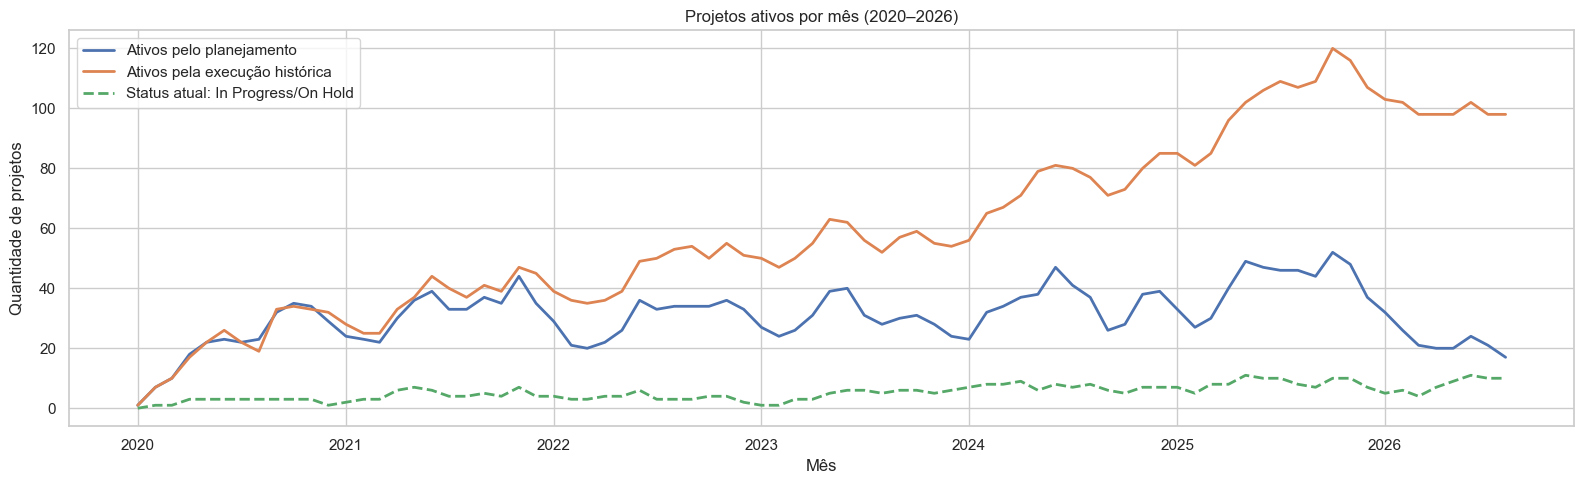

Pico de projetos ativos (planejado): 52
Média mensal de projetos ativos (planejado): 30.8


In [26]:
plt.figure(figsize=(16, 5))

plt.plot(
    pd.to_datetime(monthly_snapshot["month_start"]),
    monthly_snapshot["active_planned_projects"],
    label="Ativos pelo planejamento",
    linewidth=2,
)

plt.plot(
    pd.to_datetime(monthly_snapshot["month_start"]),
    monthly_snapshot["active_historical_projects"],
    label="Ativos pela execução histórica",
    linewidth=2,
)

plt.plot(
    pd.to_datetime(monthly_snapshot["month_start"]),
    monthly_snapshot["active_current_projects"],
    label="Status atual: In Progress/On Hold",
    linewidth=2,
    linestyle="--",
)

plt.title("Projetos ativos por mês (2020–2026)")
plt.xlabel("Mês")
plt.ylabel("Quantidade de projetos")
plt.legend()
plt.tight_layout()
plt.show()

print("Pico de projetos ativos (planejado):", monthly_snapshot["active_planned_projects"].max())
print("Média mensal de projetos ativos (planejado):", round(monthly_snapshot["active_planned_projects"].mean(), 2))

> **Insight:** observe se o pico de simultaneidade ocorre em meses
> específicos (ex.: entre março e novembro, conforme a sazonalidade
> definida na geração dos dados) e se há uma tendência de
> crescimento ao longo dos anos, refletindo a expansão do volume
> de projetos entre 2020 e 2025.

### Sazonalidade: início de projetos por mês do ano

Agrupamos todos os anos para identificar o padrão sazonal médio
de novos projetos por mês.

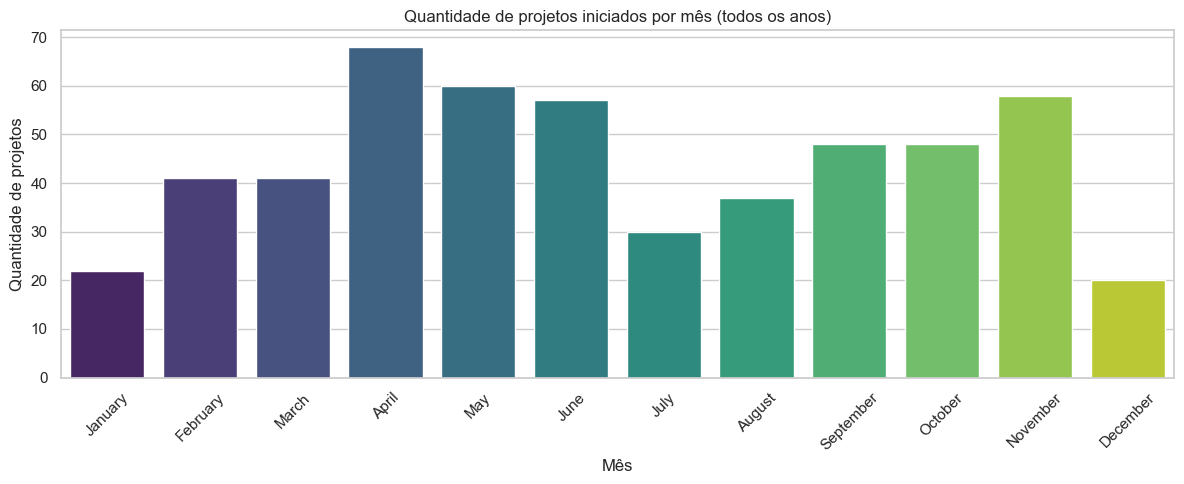

In [29]:
seasonality = (
    analytics.groupby("start_month_name")["project_id"]
    .count()
    .reindex([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ])
)

plt.figure(figsize=(12, 5))
# sns.barplot(x=seasonality.index, y=seasonality.values, palette="viridis")
sns.barplot(x=seasonality.index, y=seasonality.values, hue=seasonality.index, palette="viridis", legend=False,)
plt.title("Quantidade de projetos iniciados por mês (todos os anos)")
plt.xlabel("Mês")
plt.ylabel("Quantidade de projetos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Insight:** abril é o mês com maior volume histórico de inícios,
> seguido por maio, novembro e junho. Dezembro e janeiro apresentam
> os menores volumes, enquanto julho também registra uma redução
> relevante. Esse padrão sugere menor capacidade de mobilização no
> início e no encerramento do ano, com maior concentração de novos
> projetos entre abril e junho.

## 6. Exportação das tabelas analíticas

Por fim, exportamos as duas tabelas geradas para a pasta
`data/processed`, que serão utilizadas no dashboard de BI e nas
próximas etapas de modelagem analítica.

In [32]:
project_analytics_path = PROCESSED_DIR / "project_analytics.csv"
monthly_snapshot_path = PROCESSED_DIR / "monthly_portfolio_snapshot.csv"

analytics.to_csv(project_analytics_path, index=False)
monthly_snapshot.to_csv(monthly_snapshot_path, index=False)

print("Arquivos exportados com sucesso:")
print(f"- {project_analytics_path}")
print(f"- {monthly_snapshot_path}")

Arquivos exportados com sucesso:
- /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/project_analytics.csv
- /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/monthly_portfolio_snapshot.csv


In [33]:
# Validação rápida das novas colunas
colunas_esperadas = [
    "start_variance_days",
    "end_variance_days",
    "schedule_risk_flag",
    "cost_risk_flag",
]

for coluna in colunas_esperadas:
    status = "OK" if coluna in analytics.columns else "AUSENTE"
    print(f"{coluna}: {status}")

print("\nTotal de colunas no dataframe:", analytics.shape[1])

start_variance_days: OK
end_variance_days: OK
schedule_risk_flag: OK
cost_risk_flag: OK

Total de colunas no dataframe: 41


In [34]:
cd ~/Desktop/projetos_BI/projeto-03-project-portfolio-management

/Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management


In [35]:
df = pd.read_csv('data/processed/project_analytics.csv')

print('schedule_risk_flag:')
print(df['schedule_risk_flag'].value_counts(dropna=False))

print()
print('cost_risk_flag:')
print(df['cost_risk_flag'].value_counts(dropna=False))

print()
print('start_variance_days (describe):')
print(df['start_variance_days'].describe())

print()
print('end_variance_days (describe):')
print(df['end_variance_days'].describe())

schedule_risk_flag:
schedule_risk_flag
0.0    185
1.0    175
NaN    170
Name: count, dtype: int64

cost_risk_flag:
cost_risk_flag
1.0    220
NaN    170
0.0    140
Name: count, dtype: int64

start_variance_days (describe):
count    525.000000
mean       3.276190
std        3.671364
min       -2.000000
25%        0.000000
50%        2.000000
75%        6.000000
max       14.000000
Name: start_variance_days, dtype: float64

end_variance_days (describe):
count    434.000000
mean     -12.336406
std       37.905769
min     -202.000000
25%      -20.000000
50%       -2.500000
75%        5.750000
max      103.000000
Name: end_variance_days, dtype: float64


## 7. Síntese de insights

- A base cobre **530 projetos** entre 2020 e 2026, com variação
  anual de volume e sazonalidade mensal condizente com o esperado.
- Os meses de **janeiro, fevereiro, julho e dezembro** apresentam
  consistentemente menor volume de novos projetos.
- O indicador de **entrega no prazo** e **entrega dentro do
  orçamento** revela o nível de previsibilidade da operação.
- A análise de **simultaneidade** identifica os períodos de maior
  pressão sobre a capacidade da equipe, informando decisões de
  alocação de recursos.
- As tabelas `project_analytics.csv` e `monthly_portfolio_snapshot.csv`
  estão prontas para alimentar o dashboard executivo e servir de
  insumo para modelos preditivos (ex.: risco de atraso, risco de
  estouro de orçamento).